# Month 2 — Reliability Layer: Probability Calibration & Subgroup Fairness Analysis

This notebook implements Month 2 of the research framework:
1. **Probability Calibration**: Evaluates uncalibrated predictions, Platt Scaling (logistic sigmoid), and Isotonic Regression across models using out-of-fold nested CV predictions to prevent leakage. Reports Brier Score and Expected Calibration Error (ECE) and plots calibration curves saved to `results/`.
2. **Subgroup Fairness Analysis**: Breaks down classification performance (Accuracy, Recall, ROC-AUC) across sex (Male/Female) and age bands (`<50`, `50-60`, `>60`), reporting sample sizes with explicit methodological caveats.


In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure src module is in python path
sys.path.append('..')

from src.preprocessing import load_data
from src.evaluation import evaluate_nested_cv
from src.calibration import plot_calibration_curves
from src.fairness import compute_fairness_breakdown

# Load configuration
with open('../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded successfully.")


Configuration loaded successfully.


## 1. Execute Out-of-Fold Nested Cross-Validation Pipeline
Run 5-fold outer / 3-fold inner nested CV. Out-of-fold test predictions and calibrated probabilities (Platt Scaling & Isotonic Regression fitted strictly on fold training sets) are collected automatically.


In [2]:
raw_data_path = '../' + config['dataset']['raw_path']
df = load_data(raw_data_path)

print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

print("Running nested cross-validation with out-of-fold calibration tracking...")
results = evaluate_nested_cv(
    df,
    target_col='target',
    outer_splits=config['cv']['outer_folds'],
    inner_splits=config['cv']['inner_folds'],
    n_trials=config['cv']['optuna_n_trials'],
    random_state=config['random_state']
)

print("Nested CV evaluation completed.")


Dataset Loaded: 303 rows, 14 columns
Running nested cross-validation with out-of-fold calibration tracking...


Nested CV evaluation completed.


## 2. Probability Calibration Analysis
Compare Uncalibrated vs. Platt Scaling vs. Isotonic Regression across Random Forest, XGBoost, AdaBoost, and Soft-Voting Ensemble using Brier Score and Expected Calibration Error (ECE).


In [3]:
cal_rows = []

for model_name, m_data in results.items():
    cal = m_data['calibration']
    for method in ['uncalibrated', 'platt', 'isotonic']:
        cal_rows.append({
            'Model': model_name.upper(),
            'Calibration Method': method.capitalize(),
            'Brier Score (Lower is better)': f"{cal[method]['brier']:.4f}",
            'ECE (Lower is better)': f"{cal[method]['ece']:.4f}"
        })

cal_summary_df = pd.DataFrame(cal_rows)
print("=== Probability Calibration Comparison (Out-Of-Fold Nested CV) ===")
print(cal_summary_df.to_string(index=False))


=== Probability Calibration Comparison (Out-Of-Fold Nested CV) ===
        Model Calibration Method Brier Score (Lower is better) ECE (Lower is better)
RANDOM_FOREST       Uncalibrated                        0.1244                0.0877
RANDOM_FOREST              Platt                        0.1273                0.0858
RANDOM_FOREST           Isotonic                        0.1316                0.0977
      XGBOOST       Uncalibrated                        0.1223                0.0393
      XGBOOST              Platt                        0.1285                0.0837
      XGBOOST           Isotonic                        0.1279                0.0854
     ADABOOST       Uncalibrated                        0.1506                0.1708
     ADABOOST              Platt                        0.1212                0.0740
     ADABOOST           Isotonic                        0.1238                0.0809
     ENSEMBLE       Uncalibrated                        0.1255                0.100

### Plot Calibration Curves
Generate and save calibration curve plots for each model to `results/`.


Saved calibration curve: ../results/random_forest_calibration_curve.png


Saved calibration curve: ../results/xgboost_calibration_curve.png


Saved calibration curve: ../results/adaboost_calibration_curve.png


Saved calibration curve: ../results/ensemble_calibration_curve.png

Displaying Ensemble Calibration Curve:


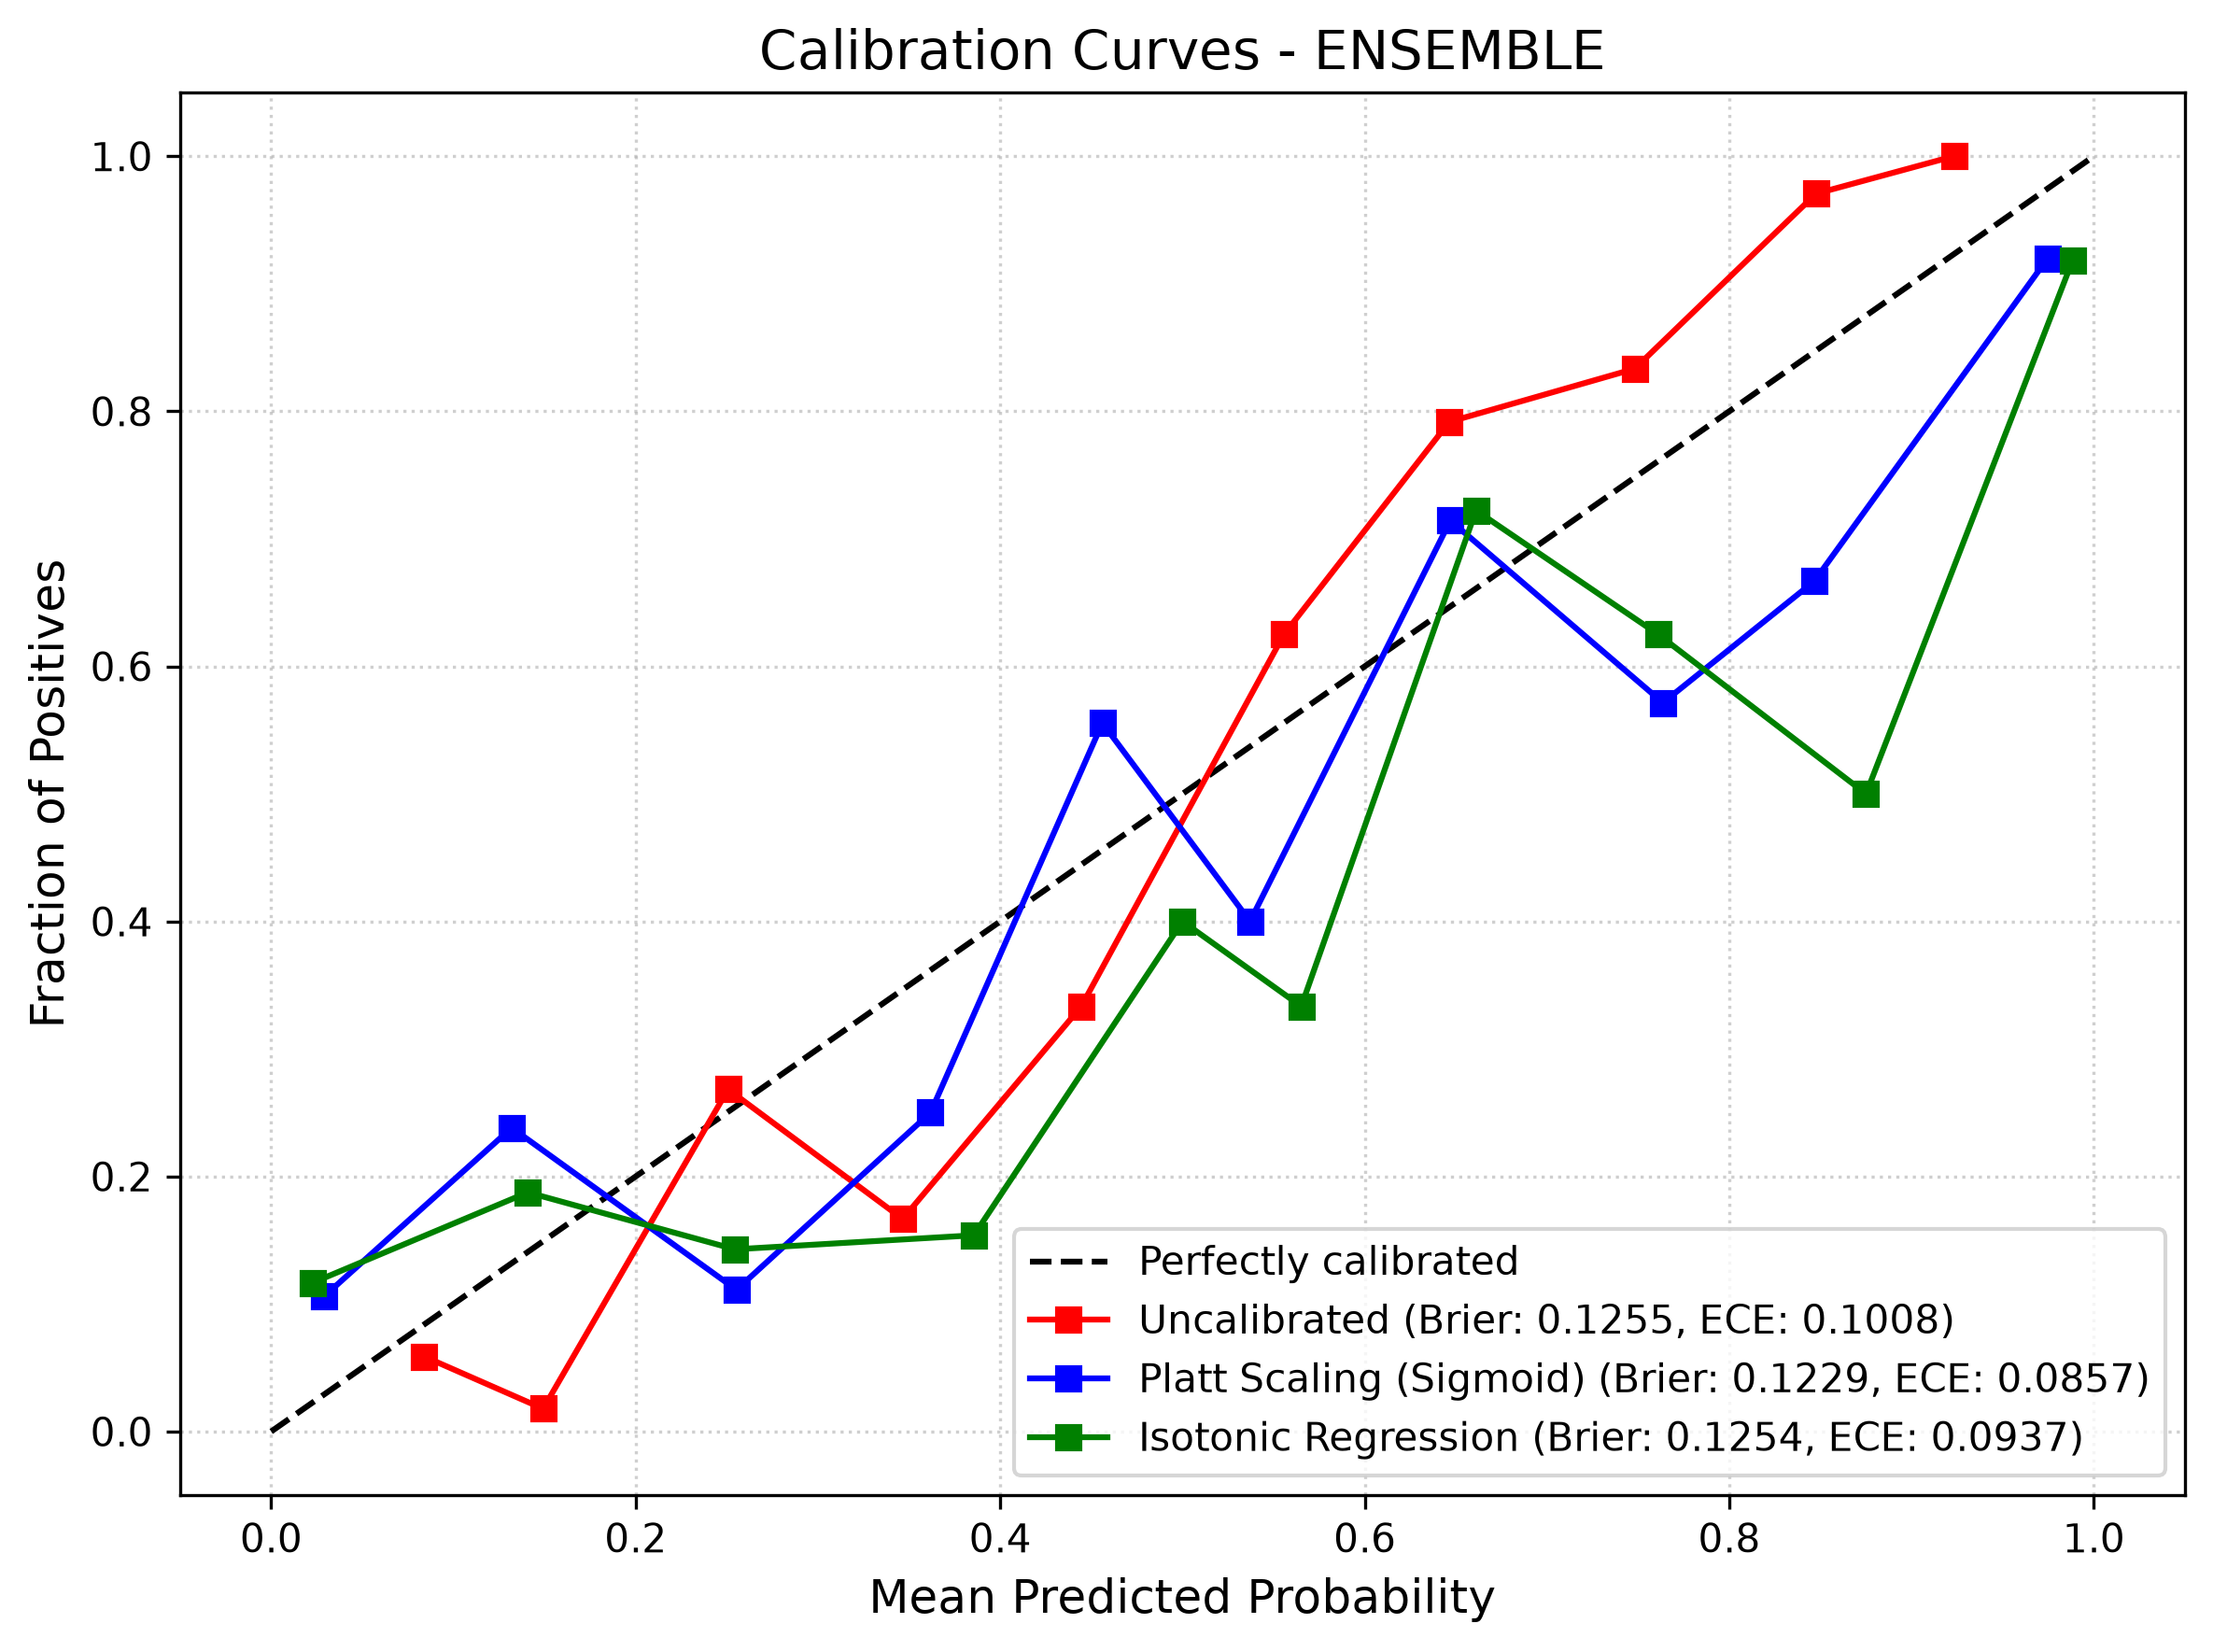

In [4]:
results_dir = '../' + config['results_dir']

for model_name, m_data in results.items():
    curve_path = plot_calibration_curves(
        m_data['calibration'],
        model_name=model_name,
        output_dir=results_dir,
        n_bins=10
    )
    print(f"Saved calibration curve: {curve_path}")

print("\nDisplaying Ensemble Calibration Curve:")
display(Image(filename=f"{results_dir}/ensemble_calibration_curve.png"))


## 3. Subgroup Fairness Analysis
Evaluate prediction performance across demographic subgroups (`sex` and `age_band`).


In [5]:
ensemble_oof = results['ensemble']['out_of_fold_predictions']
oof_df = df.iloc[ensemble_oof['test_indices']].reset_index(drop=True)

y_true_oof = np.array(ensemble_oof['y_true'])
y_pred_oof = np.array(ensemble_oof['y_pred'])
y_prob_oof = np.array(ensemble_oof['y_prob_platt'])  # Using Platt calibrated probabilities

fairness_res = compute_fairness_breakdown(
    oof_df, y_true_oof, y_pred_oof, y_prob_oof, target_col='target'
)

print(f"=== {fairness_res['caveat']} ===\n")

print("--- Performance Breakdown by Sex ---")
print(fairness_res['sex_breakdown'].to_string(index=False))

print("\n--- Performance Breakdown by Age Band ---")
print(fairness_res['age_breakdown'].to_string(index=False))


=== NOTE / CAVEAT: Subgroup sample sizes in healthcare datasets (such as Cleveland) are small (e.g. N < 100 per subgroup). Performance breakdowns across subgroups should be interpreted as indicative/exploratory rather than statistically conclusive. ===

--- Performance Breakdown by Sex ---
  subgroup  sample_size  accuracy   recall  roc_auc
Female (0)           97  0.907216 0.720000 0.928889
  Male (1)          206  0.820388 0.815789 0.884630

--- Performance Breakdown by Age Band ---
subgroup  sample_size  accuracy   recall  roc_auc
   50-60          137  0.824818 0.797101 0.909847
    < 50           87  0.908046 0.730769 0.927491
    > 60           79  0.822785 0.840909 0.846104
